In [37]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
spark = SparkSession.builder.appName("Read Parquet").getOrCreate()
# read in all the data across the times
year_2026_01 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-01.parquet")
year_2026_02 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-02.parquet")
year_2026_03 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-03.parquet")
year_2026_04 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-04.parquet")
year_2026_05 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-05.parquet")
data = year_2026_01.union(year_2026_02).union(year_2026_03).union(year_2026_04).union(year_2026_05)
data.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



# Calculating trip duration and revenue per minute

In [38]:
import geopandas as gpd
taxi_zones = gpd.read_file('data/taxi_zones/taxi_zones.shp')
print(taxi_zones.dtypes)
taxi_zones.head()

OBJECTID         int32
Shape_Leng     float64
Shape_Area     float64
zone               str
LocationID       int32
borough            str
geometry      geometry
dtype: object


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [39]:
raw_weather_data = spark.read.csv("data/weather.csv", header=True, inferSchema=True)
print(raw_weather_data.columns)

['STATION', 'NAME', 'DATE', 'AWND', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TOBS', 'WDF2', 'WDF5', 'WESD', 'WESF', 'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08', 'WT09', 'WT11']


In [40]:
raw_weather_data = raw_weather_data.filter(
    F.col('STATION').isin(['USW00014732', 'USW00094789'])  # LaGuardia + JFK
)

In [41]:
weather_df = raw_weather_data.filter(raw_weather_data['NAME'].contains('LAGUARDIA')).select('DATE', 'PRCP', 'SNOW', 'TMAX', 'TMIN')
weather_df = weather_df.withColumn('TAVG', (F.col('TMAX') + F.col('TMIN')) / 2)
weather_df.show()

+----------+----+----+----+----+----+
|      DATE|PRCP|SNOW|TMAX|TMIN|TAVG|
+----------+----+----+----+----+----+
|2026-01-01| 0.0| 0.0|  36|  23|29.5|
|2026-01-02| 0.0| 0.0|  30|  20|25.0|
|2026-01-03| 0.0| 0.0|  31|  24|27.5|
|2026-01-04| 0.0| 0.0|  35|  26|30.5|
|2026-01-05| 0.0| 0.0|  38|  30|34.0|
|2026-01-06|0.01| 0.0|  39|  35|37.0|
|2026-01-07|0.01| 0.0|  48|  36|42.0|
|2026-01-08| 0.0| 0.0|  50|  37|43.5|
|2026-01-09| 0.0| 0.0|  54|  35|44.5|
|2026-01-10|0.46| 0.0|  53|  38|45.5|
|2026-01-11|0.02| 0.0|  47|  34|40.5|
|2026-01-12| 0.0| 0.0|  41|  32|36.5|
|2026-01-13| 0.0| 0.0|  47|  37|42.0|
|2026-01-14| 0.0| 0.0|  51|  42|46.5|
|2026-01-15| 0.0| 0.0|  46|  25|35.5|
|2026-01-16| 0.0| 0.0|  34|  22|28.0|
|2026-01-17|0.17| 1.4|  40|  31|35.5|
|2026-01-18|0.26| 1.5|  35|  31|33.0|
|2026-01-19| 0.0| 0.0|  33|  24|28.5|
|2026-01-20| 0.0| 0.0|  27|  17|22.0|
+----------+----+----+----+----+----+
only showing top 20 rows


In [42]:
daily_aggregated_data = data
daily_aggregated_data = (
    data
    .groupBy(
        F.to_date("tpep_pickup_datetime").alias("date"),
        "PULocationID"
    )
    .agg(
        F.sum("total_amount").alias("daily_revenue")
    )
    .orderBy("date", "PULocationID")
).sort('PULocationID', 'date')
print(daily_aggregated_data.count())
daily_aggregated_data.show()

36765
+----------+------------+------------------+
|      date|PULocationID|     daily_revenue|
+----------+------------+------------------+
|2026-01-01|           1|3848.2300000000005|
|2026-01-02|           1|           3044.13|
|2026-01-03|           1|2981.3399999999997|
|2026-01-04|           1| 4814.719999999999|
|2026-01-05|           1|2216.2799999999997|
|2026-01-06|           1|2014.4499999999998|
|2026-01-07|           1|            723.88|
|2026-01-08|           1|            587.96|
|2026-01-09|           1| 802.8199999999999|
|2026-01-10|           1|            885.02|
|2026-01-11|           1|             809.4|
|2026-01-12|           1|           1045.06|
|2026-01-13|           1|           1406.75|
|2026-01-14|           1|           1382.54|
|2026-01-15|           1|           2014.62|
|2026-01-16|           1|            1414.9|
|2026-01-17|           1|1278.1000000000001|
|2026-01-18|           1|1118.5900000000001|
|2026-01-19|           1|2250.8100000000004|
|202

In [43]:
def calculate_expected_daily_revenue(id, aggregated_data, geospatial_data):
    """
    Calculate expected daily revenue for a location based on its geographic neighbors.
    
    Args:
        id (int): PULocationID for the zone of interest
        aggregated_data (Spark DataFrame): Contains columns [date, PULocationID, daily_revenue]
    
    Returns:
        Spark DataFrame: Original aggregated_data with added column 'expected_daily_revenue'
    """
    
    # Get the geometry of the zone of interest (using GeoPandas, not Spark)
    zone_row = geospatial_data[geospatial_data['OBJECTID'] == id]
    if zone_row.empty:
        return aggregated_data
    
    zone_geometry = zone_row.iloc[0]['geometry']
    
    # Find neighboring zones using GeoPandas
    neighbor_mask = geospatial_data.geometry.touches(zone_geometry)
    neighbor_ids = geospatial_data[neighbor_mask]['OBJECTID'].tolist()
    
    # Filter to zone of interest and join
    zone_data = aggregated_data.filter(
        F.col('PULocationID') == id
    )
    # Fill any NULLs with city average
    city_avg = aggregated_data.agg(
        F.avg('daily_revenue')
    ).collect()[0][0]

    # If no neighbors found, use city average as fallback
    if not neighbor_ids:
        return zone_data.withColumn(
            'expected_daily_revenue',
            F.lit(city_avg)
        )
    
    # Get daily revenue for neighbors (using Spark)
    neighbor_data = aggregated_data.filter(
        F.col('PULocationID').isin(neighbor_ids)
    ).groupBy('date').agg(
        F.avg('daily_revenue').alias('expected_daily_revenue')
    )
    result = zone_data.join(
        neighbor_data,
        on='date',
        how='left'
    )


    
    result = result.withColumn(
        'expected_daily_revenue',
        F.coalesce(F.col('expected_daily_revenue'), F.lit(city_avg))
    ).sort('date')
    return result

In [44]:
expected_performance = calculate_expected_daily_revenue(139, daily_aggregated_data, taxi_zones)
expected_performance.show()

+----------+------------+------------------+----------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|
+----------+------------+------------------+----------------------+
|2026-01-01|         139|             573.3|               640.195|
|2026-01-02|         139|            789.19|    1101.8750000000002|
|2026-01-03|         139|            280.75|               788.155|
|2026-01-04|         139|            247.81|     914.9650000000001|
|2026-01-05|         139|            934.44|              1763.795|
|2026-01-06|         139|504.17999999999995|              1403.775|
|2026-01-07|         139|            942.21|               1607.19|
|2026-01-08|         139|            738.95|    1224.3449999999998|
|2026-01-09|         139|           1208.14|     919.8050000000001|
|2026-01-10|         139|            332.52|               778.435|
|2026-01-11|         139|            475.89|    1396.1550000000002|
|2026-01-12|         139|           1188.62|    

In [ ]:
import pandas as pd
# Convert PySpark DataFrame to Pandas for plotting
taxi_underperformers_sub = expected_performance.select("date", "daily_revenue", 'expected_daily_revenue') \
    .orderBy("date") \
    .toPandas()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(taxi_underperformers_sub["date"], taxi_underperformers_sub["daily_revenue"], label="Actual Daily Revenue")
plt.plot(taxi_underperformers_sub["date"], taxi_underperformers_sub["expected_daily_revenue"], label="Expected Daily Revenue")
plt.xlim(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-05-31'))
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.title("Total Amount over Time for Taxi Underperformers")
plt.legend()
plt.tight_layout()
plt.show()

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


In [ ]:
rainy_days = weather_df.filter(F.col("PRCP") > 0)

+----------+----+----+----+----+----+
|      DATE|PRCP|SNOW|TMAX|TMIN|TAVG|
+----------+----+----+----+----+----+
|2026-01-06|0.01| 0.0|  39|  35|37.0|
|2026-01-07|0.01| 0.0|  48|  36|42.0|
|2026-01-10|0.46| 0.0|  53|  38|45.5|
|2026-01-11|0.02| 0.0|  47|  34|40.5|
|2026-01-17|0.17| 1.4|  40|  31|35.5|
|2026-01-18|0.26| 1.5|  35|  31|33.0|
|2026-01-25|1.15| 9.7|  24|  11|17.5|
|2026-01-26|0.13| 0.4|  27|  19|23.0|
|2026-02-11|0.03| 0.0|  42|  31|36.5|
|2026-02-15|0.03| 0.3|  39|  29|34.0|
|2026-02-16|0.04| 0.7|  39|  30|34.5|
|2026-02-18|0.09| 0.0|  39|  35|37.0|
|2026-02-20|0.36| 0.0|  39|  33|36.0|
|2026-02-22|0.46| 8.1|  35|  31|33.0|
|2026-02-23|1.52|15.3|  36|  29|32.5|
|2026-02-25|0.09| 1.3|  44|  27|35.5|
|2026-03-03|0.31| 0.0|  35|  30|32.5|
|2026-03-04|0.02| 0.0|  50|  35|42.5|
|2026-03-05|1.32| 0.0|  45|  37|41.0|
|2026-03-06|0.21| 0.0|  41|  36|38.5|
+----------+----+----+----+----+----+
only showing top 20 rows


/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


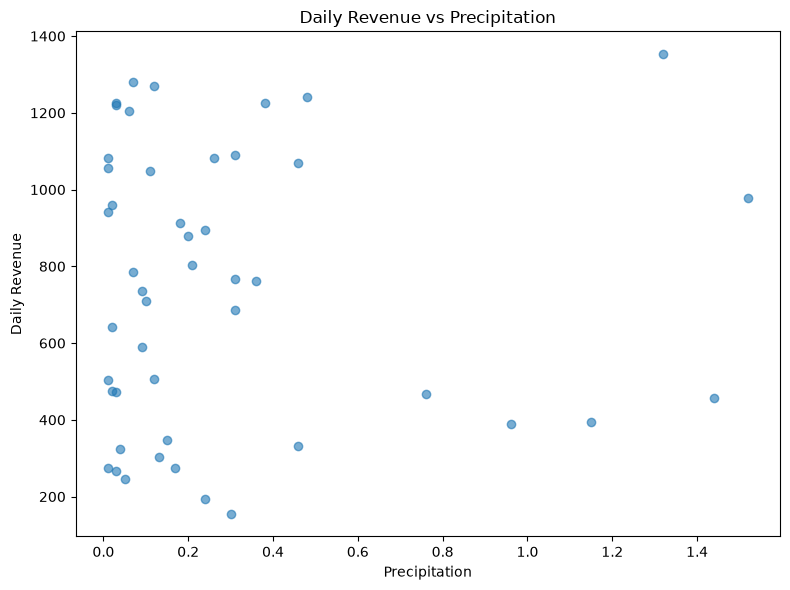

In [ ]:
# Join precipitation with daily revenue by date
precip_revenue_df = (
    expected_performance
    .join(
        rainy_days.select(F.to_date("DATE").alias("date"), F.col("PRCP")),
        on="date",
        how="inner"
    )
    .select("PRCP", "daily_revenue")
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    precip_revenue_df["PRCP"],
    precip_revenue_df["daily_revenue"],
    alpha=0.6
)
plt.xlabel("Precipitation")
plt.ylabel("Daily Revenue")
plt.title("Daily Revenue vs Precipitation")
plt.tight_layout()
plt.show()